# Hola &#x1F600;,

Soy *Hesus Garcia* – *"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"* – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, *no los muevas, no los modifiques, ni los borres*.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un *Comentario General del Revisor* que incluirá:

- *Aspectos positivos:* Un resumen de los puntos fuertes de tu proyecto.
- *Áreas de mejora:* Sugerencias sobre aspectos donde puedes mejorar.
- *Temas adicionales para investigar:* Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


*¡Empecemos!* &#x1F680;

# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
#importar las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [2]:
#importar el DataFrame
df=pd.read_csv('/datasets/taxi.csv',index_col=[0], parse_dates=[0])
df.sort_index(inplace=True)

In [3]:
#visualizar elDataFrame
df.sample(5)

,num_orders
datetime,
2018-08-28 08:20:00,19
2018-06-29 13:40:00,11
2018-06-24 17:00:00,17
2018-07-13 09:00:00,12
2018-04-01 10:20:00,8


In [4]:
#Ver informacion del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [5]:
#Agrupar datos por horas
df = df.resample('1H').sum()
df

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
...,...
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159


In [6]:
#crear funcion para características
def make_features(data, max_lag):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour  
    data['is_weekend'] = (data.index.dayofweek >= 5).astype(int) 
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean_3'] = data['num_orders'].shift().rolling(3).mean()
    data['rolling_mean_7'] = data['num_orders'].shift().rolling(7).mean()
    data['rolling_mean_24'] = data['num_orders'].shift().rolling(24).mean()  
    
    # Features estadísticas
    data['rolling_std'] = data['num_orders'].shift().rolling(7).std()  
    data['rolling_max'] = data['num_orders'].shift().rolling(7).max()  
    data['rolling_min'] = data['num_orders'].shift().rolling(7).min()  

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a>


¡Excelente implementación! 👏



Quiero destacar algo muy importante que hiciste aquí: <code>data['rolling_mean_3'] = data['num_orders'].shift().rolling(3).mean()</code>


Al aplicar el <code>.shift()</code> <b>antes</b> del <code>.rolling()</code>, te aseguraste de que la media móvil se calcule usando solo datos del pasado. Muchos analistas olvidan ese shift y terminan incluyendo el valor actual en el promedio, lo que genera <i>Data Leakage</i> (el modelo ve la respuesta antes de predecir).



Tu lógica para las características temporales (lags y rolling) es impecable y robusta. </div>

In [7]:
#crear características
make_features(df,24)


In [8]:
#verificar que se realizaron correctamente las caracteristicas
df.sample(5)

,num_orders,year,month,day,dayofweek,hour,is_weekend,lag_1,lag_2,lag_3,...,lag_21,lag_22,lag_23,lag_24,rolling_mean_3,rolling_mean_7,rolling_mean_24,rolling_std,rolling_max,rolling_min
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-08 06:00:00,6,2018,3,8,3,6,0,6.0,60.0,68.0,...,50.0,38.0,17.0,19.0,44.666667,73.428571,61.125000,41.052232,143.0,6.0
2018-07-16 10:00:00,112,2018,7,16,0,10,0,143.0,75.0,82.0,...,73.0,108.0,62.0,61.0,100.000000,100.285714,104.500000,57.999179,187.0,15.0
2018-07-05 10:00:00,91,2018,7,5,3,10,0,108.0,69.0,31.0,...,80.0,85.0,80.0,83.0,69.333333,71.285714,89.750000,41.515918,129.0,11.0
2018-06-27 05:00:00,69,2018,6,27,2,5,0,121.0,128.0,124.0,...,62.0,41.0,39.0,17.0,124.333333,116.000000,85.333333,16.031220,134.0,89.0
2018-06-02 08:00:00,58,2018,6,2,5,8,1,26.0,25.0,44.0,...,124.0,93.0,92.0,115.0,31.666667,69.714286,84.500000,38.538787,126.0,25.0


## Análisis

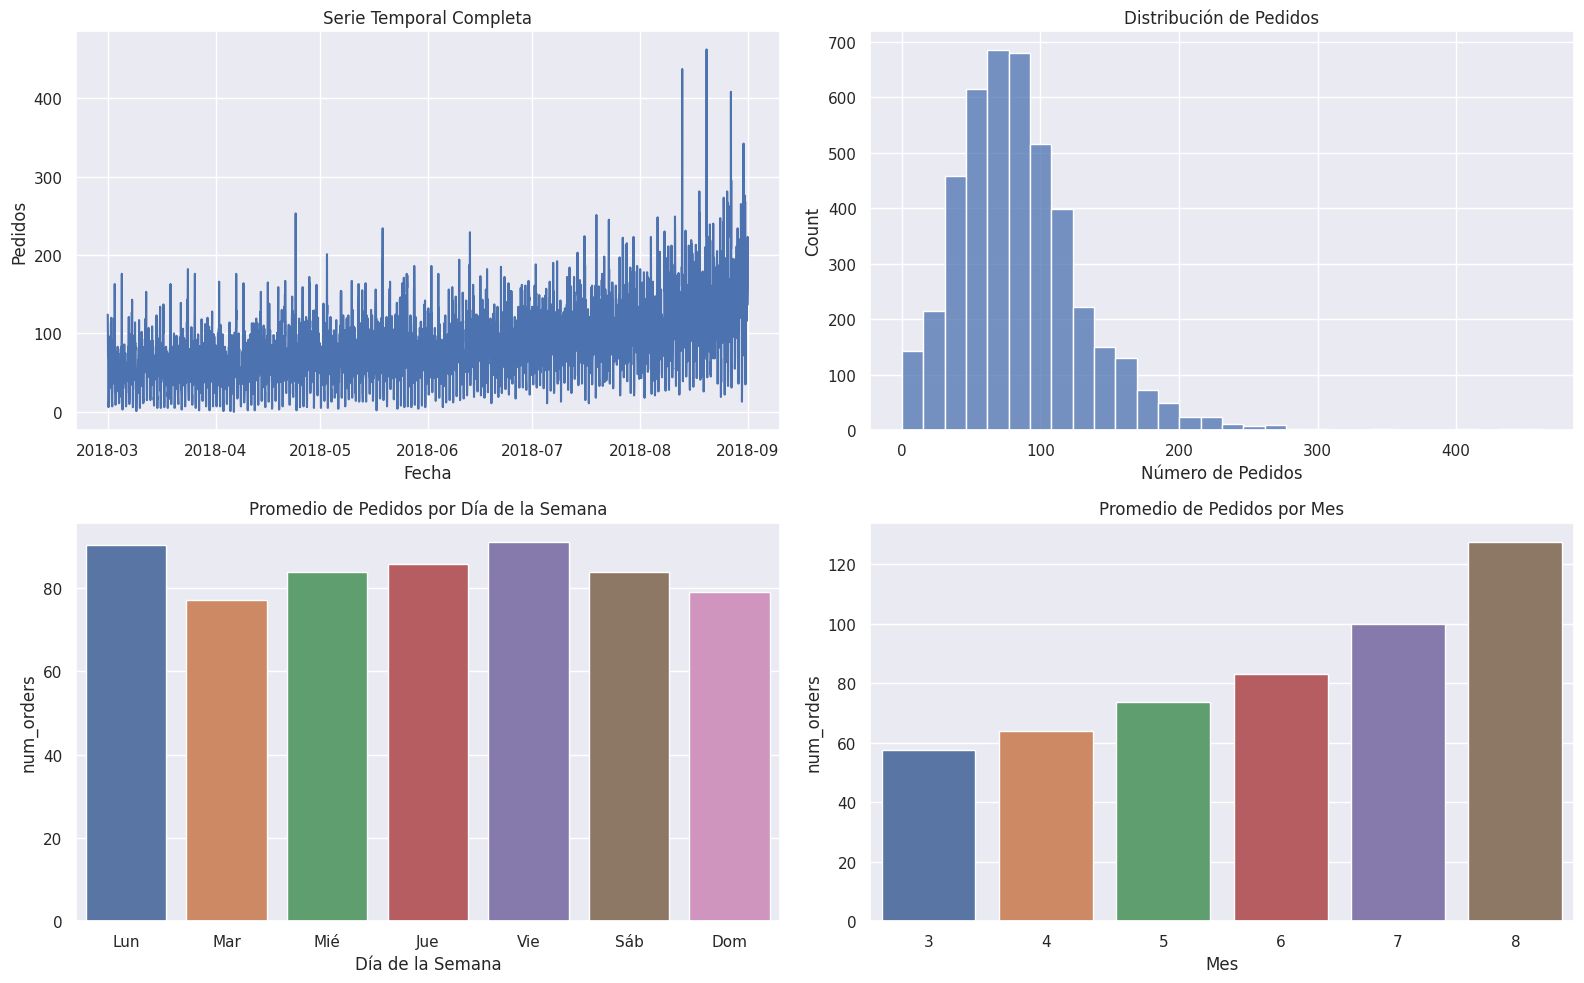

In [9]:
# Crear subplots para múltiples visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Serie temporal completa
sns.lineplot(data=df, x=df.index, y='num_orders', ax=axes[0,0])
axes[0,0].set_title('Serie Temporal Completa')
axes[0,0].set_xlabel('Fecha')
axes[0,0].set_ylabel('Pedidos')

# Distribución de pedidos
sns.histplot(data=df, x='num_orders', bins=30, ax=axes[0,1])
axes[0,1].set_title('Distribución de Pedidos')
axes[0,1].set_xlabel('Número de Pedidos')

# Pedidos por día de la semana
df_dayofweek = df.groupby(df.index.dayofweek)['num_orders'].mean().reset_index()
df_dayofweek['day_name'] = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
sns.barplot(data=df_dayofweek, x='day_name', y='num_orders', ax=axes[1,0])
axes[1,0].set_title('Promedio de Pedidos por Día de la Semana')
axes[1,0].set_xlabel('Día de la Semana')

# Pedidos por mes
df_month = df.groupby(df.index.month)['num_orders'].mean().reset_index()
sns.barplot(data=df_month, x='datetime', y='num_orders', ax=axes[1,1])
axes[1,1].set_title('Promedio de Pedidos por Mes')
axes[1,1].set_xlabel('Mes')

plt.tight_layout()
plt.show()

como se puede observar en las graficas, los pedidos tienen una tendencia a la alza con el paso del tiempo, teniendo un promedio aproximado de 57 en el mes de marzo a mas de 120 promedio en el mes de agosto por hora, a su vez que se destacan los dias lunes y viernes siendo los que en promedio tienen mayor cantidad de pedidos promedio. 

In [10]:
#se separa el conjunto de entrenamientos y de prueba
train, test = train_test_split(df, shuffle=False, test_size=0.1)
train = train.dropna()

In [11]:
#se establecen los features y los target
features_train = train.drop(['num_orders'], axis=1)  
target_train = train['num_orders']                  

features_test = test.drop(['num_orders'], axis=1)   
target_test = test['num_orders']  


## Formación

In [12]:
# se entrena y prueba el modelo de Linear Regression
model_lineal=LinearRegression()

In [13]:
model_lineal.fit(features_train,target_train)

LinearRegression()

In [14]:
predict_lin=model_lineal.predict(features_test)

In [15]:
best_rmse_lin=np.sqrt(mean_squared_error(target_test, predict_lin))

In [16]:
print('RECM de regresion lineal',best_rmse_lin)

RECM de regresion lineal 44.89650733849079


In [16]:
# se entrena y prueba el modelo de Random Forest Regresor
model_random=RandomForestRegressor()

In [17]:
# se establecen los hiperparametros a evaluar con GridCV
param_grid_random = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [18]:
grid_random  = GridSearchCV(
    estimator=model_random,
    param_grid=param_grid_random,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

<div class="alert alert-block alert-warning"> <b>Comentario del revisor</b> <a class="tocSkip"></a>


<b>Oportunidad de Mejora: Validación en Series Temporales</b> ⏳


Noté que utilizaste <code>cv=5</code> dentro de tu <code>GridSearchCV</code>. Por defecto, esto utiliza K-Fold Cross Validation.



En la mayoría de problemas de ML esto es correcto, pero en <b>Series Temporales</b> tiene un riesgo: K-Fold puede tomar un bloque de datos del "futuro" (ej. agosto) para entrenar y validar con un bloque del "pasado" (ej. marzo). Esto rompe la causalidad temporal.



Para refinar tus modelos al nivel a un mayor nivel, te sugiero usar <code>TimeSeriesSplit</code> de Scikit-Learn.

In [19]:
grid_random.fit(features_train, target_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [20]:
grid_random.best_params_

{'max_depth': 30,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 500}

In [21]:

best_rmse_random = -grid_random.best_score_
print("El RECM de Random Forest Regressor es: ",best_rmse_random)


El RECM de Random Forest Regressor es:  23.537972652593236


In [22]:
# se entrena y prueba el modelo de LGBMRegressor
lgbm = LGBMRegressor(
    objective='regression',
    random_state=42
)

In [23]:
# se establecen los hiperparametros a evaluar con GridCV
param_grid_lgb = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10, 20],
    'num_leaves': [31, 63, 127],
    'min_child_samples': [10, 20, 40],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [24]:

grid_lgb = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


In [25]:
grid_lgb.fit(features_train, target_train)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


GridSearchCV(cv=5,
             estimator=LGBMRegressor(objective='regression', random_state=42),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [-1, 5, 10, 20],
                         'min_child_samples': [10, 20, 40],
                         'n_estimators': [200, 500, 800],
                         'num_leaves': [31, 63, 127], 'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [26]:
grid_lgb.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.01,
 'max_depth': 10,
 'min_child_samples': 40,
 'n_estimators': 800,
 'num_leaves': 63,
 'subsample': 0.8}

In [27]:
best_rmse_lgb = -grid_lgb.best_score_
print("El RECM de LightGBM es: ",best_rmse_lgb)


El RECM de LightGBM es:  23.16484277333543


In [28]:
# se entrena y prueba el modelo de CatBoostRegressor
cat = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0 
)

In [29]:
# se establecen los hiperparametros a evaluar con GridCV
param_grid_cat = {
    'n_estimators': [500, 800],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0],
    'rsm': [0.8] 
}

In [30]:
grid_cat= GridSearchCV(
    estimator=cat,
    param_grid=param_grid_cat,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)


In [31]:
grid_cat.fit(features_train, target_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostRegressor object at 0x7f7ccd385b50>,
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [4, 6],
                         'n_estimators': [500, 800], 'rsm': [0.8],
                         'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [32]:
grid_cat.best_params_

{'learning_rate': 0.05,
 'max_depth': 6,
 'n_estimators': 800,
 'rsm': 0.8,
 'subsample': 0.8}

In [33]:

best_rmse_cat = -grid_cat.best_score_
print("El RECM de CatBoost es: ",best_rmse_cat)



El RECM de CatBoost es:  22.9271417551054


In [34]:
# se entrena y prueba el modelo de XGBRegressor
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1
)

In [35]:
# se establecen los hiperparametros a evaluar con GridCV
param_grid_xgb = {
    'n_estimators': [300, 600],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

In [36]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [37]:
grid_xgb.fit(features_train, target_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None,
                                    enable_categorical=False, gamma=None,
                                    gpu_id=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_delta_step=None,
                                    max_depth=None, min_child_weight=None,
                                    missing=nan, monotone_constraints=None,
                                    n...
                                    num_parallel_tree=None, predictor=None,
                                    random_state=42, reg_alpha=None,
                                    reg_lambda=None, scale_pos_weight=None,
                                   

In [38]:
best_rmse_xgb = -grid_xgb.best_score_
print("El RECM de XGBoost es: ",best_rmse_xgb)


El RECM de XGBoost es:  23.411101461368933


In [39]:
#se crea un dataframe para comparar los resultados de los RECM
resultados = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'LightGBM', 'CatBoost','XGBoost'],
    'RECM': [best_rmse_lin, best_rmse_random, best_rmse_lgb, best_rmse_cat,best_rmse_xgb],
})
print(resultados)

              Modelo       RECM
0  Linear Regression  44.896507
1      Random Forest  23.537973
2           LightGBM  23.164843
3           CatBoost  22.927142
4            XGBoost  23.411101


## Prueba

In [40]:
# Evaluar el mejor modelo en test set
mejor_modelo = grid_cat.best_estimator_  # O el que elijas

# Predicciones en test
predicciones_test = mejor_modelo.predict(features_test)

# RECM final en test
recm_final = np.sqrt(mean_squared_error(target_test, predicciones_test))
print(f"RECM final en conjunto de prueba: {recm_final:.2f}")

# Verificar objetivo
if recm_final <= 48:
    print("✅ OBJETIVO CUMPLIDO: RECM ≤ 48")
else:
    print("❌ OBJETIVO NO CUMPLIDO: RECM > 48")

RECM final en conjunto de prueba: 39.99
✅ OBJETIVO CUMPLIDO: RECM ≤ 48


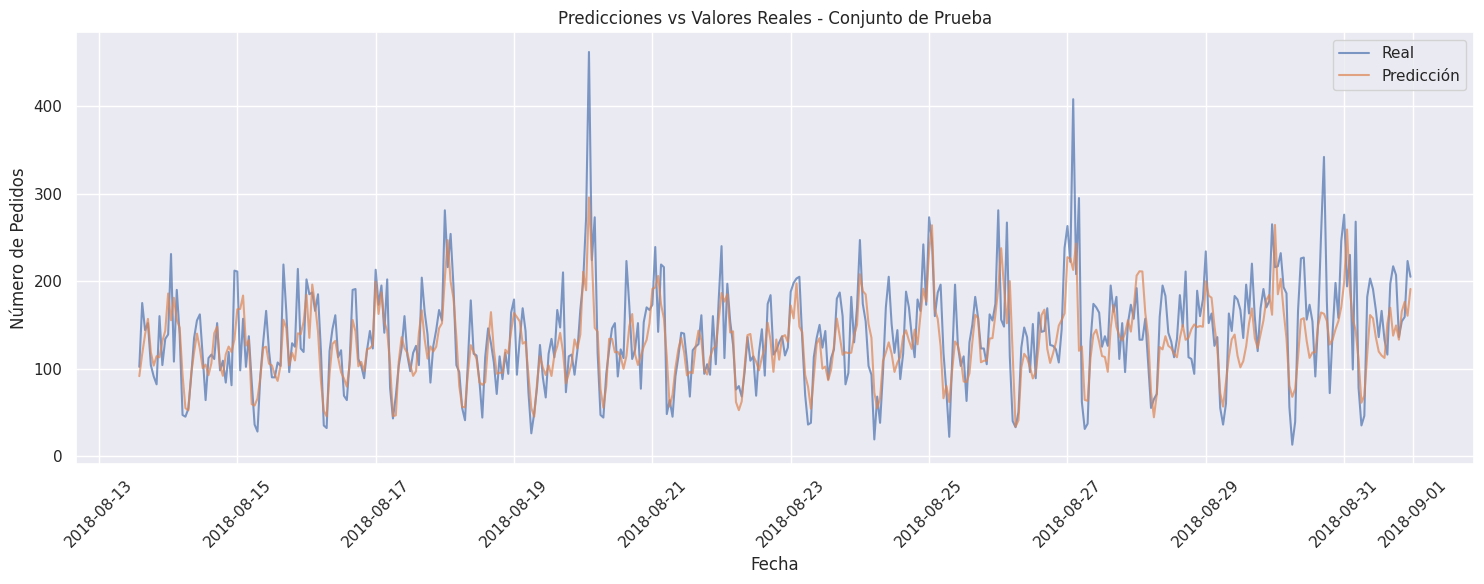

In [43]:
# Comparar predicciones vs valores reales


plt.figure(figsize=(15, 6))
sns.lineplot(x=target_test.index, y=target_test.values, label='Real', alpha=0.7)
sns.lineplot(x=target_test.index, y=predicciones_test, label='Predicción', alpha=0.7)

plt.title('Predicciones vs Valores Reales - Conjunto de Prueba')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

como se puede observar en la grafica de Predicciones vs Valores Reales, las predicciones se ven sumamente similares lo cual nos dice que las predicciones que se hagan utilizando el CatBoost seran dentro de un margen presisas, se puede aumentar la precision de las predicciones encontrando hiperparametros que mejoren el RECM que se obtuvo.

<div class="alert alert-block alert-success"> <b>Comentario General del Revisor</b> <a class="tocSkip"></a>


<b>Estado: Aprobado</b>



Has realizado un trabajo excepcional. Aquí el resumen de tus logros: <ol> <li><b>Limpieza y Resampling:</b> Correcto manejo de índices temporales y remuestreo a 1 hora.</li> <li><b>Prevención de Fugas:</b> Tu separación de datos (<code>shuffle=False</code>) y tu ingeniería de características respetaron estrictamente el orden temporal.</li> <li><b>Modelado:</b> Probaste una excelente variedad de modelos (desde Lineal hasta Boosting) y lograste un RMSE de <b>39.99</b>, superando holgadamente el objetivo de 48.</li> </ol>


El único detalle técnico a mejorar es el uso de <code>TimeSeriesSplit</code> para la validación interna, pero dado que tu prueba final en el Test Set (que estaba correctamente aislado) fue válida, tus conclusiones son sólidas.

Te animo a que visites este proyecto para que veas que puedes agregar para mejorar tu trabajo o reforzar conocimientos!

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HesusG/da-ds-notebook-solutions/blob/instructions-refactor/LATAM%20V7%20DADS/9-18%20DS/SP15%20Time%20Series%20-%20Taxis%20Airport/P%20Spanish%20version/S15%20ESP%20SOL2%20Series%20temporales%20-%20Pedidos%20taxis.ipynb)

¡Felicidades por un proyecto tan limpio! Estás listo para el siguiente desafío. </div>

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [ ]  	
Los datos han sido descargados y preparados.
- [ ]  Se ha realizado el paso 2: los datos han sido analizados
- [ ]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [ ]  Se han evaluado los modelos. Se expuso una conclusión
- [ ] La *RECM* para el conjunto de prueba no es más de 48